centrality
- Degree
- Betweenness
- Pagerank
- CI

## MultiStage mind_wrapper

### Stage 1: Preprocess


### Stage 2: Dismantling

In [1]:
import igraph as ig
import torch
from copy import deepcopy
from typing import Callable,Dict
import numpy as np
import os
from task_encoder import TaskEncoder
from networks.dismantle import load_sac_dismantler,load_sac_dismantler_with_film
import utils
import importlib
import baseline
importlib.reload(utils)
importlib.reload(baseline)
from baseline import ensure_attribute
  
def mind_wrapper(graph:ig.Graph,ckpt_pth=None,gnn='mind',**kwargs):
    '''
    same return with preprocess
    removals: complete solution
    removed_sizes: cumulative removed number at each step, start from 0
    lcc_sizes: lcc size at each step, len(lcc_sizes) = len(removed_sizes)
    '''
    graph = deepcopy(graph)
    ensure_attribute(graph)

    device: str='cuda:0'
    # device = torch.device('cpu')
    
    gnn = ckpt_pth.split("/")[1]
    info = os.path.basename(os.path.dirname(ckpt_pth))
    print(info)

    F = 16; H = 4; K = 6
    latent_dim = 16
    ckpt = torch.load(ckpt_pth, map_location=device)

    from utils.validate import validate_one_graph
    if "task" in info:
        task_encoder = TaskEncoder(F, H, K, gnn, hidden_dim=128, latent_dim=latent_dim).to(device)
        if "task_encoder_state_dict" in ckpt:
            task_encoder.load_state_dict(ckpt["task_encoder_state_dict"])
        if "film" in info:
            policy, _, _, _, _, _ = load_sac_dismantler_with_film(F, H, K, gnn, device, latent_dim, ckpt_pth)

    else:
        policy, _, _, _, _ = load_sac_dismantler(F, H, K, gnn, device, ckpt_pth)
    auc, robustness, _, removals = validate_one_graph(graph,policy=policy,log_removals=True)
    
    return auc, robustness, removals


from utils.common import load_g
G = load_g("graphs/simple/simple_100.pkl",name="test")
test_auc, test_robustness, test_removals = mind_wrapper(
    G,
    # ckpt_pth = 'saved/mind/mind.ckpt',
    ckpt_pth= 'saved/hgnn_v4/sac_graph_task_frozen_film_20260130_191042/13999.ckpt',
    step_ratio = 0
)


import baseline
import importlib
importlib.reload(baseline)
from baseline import evaluate_sol
test_auc, test_robustness = evaluate_sol(G,test_removals)
print(test_auc,test_robustness)



d:\Anaconda3\envs\torch_py38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sac_graph_task_frozen_film_20260130_191042
Loaded graph test
Graph: test, AUC=48.286667, Robustness=0.478400, Steps=89
48.28666666666667 0.48830000000000007


mind
Loaded graph test
Graph: test, AUC=52.803431, Robustness=0.307958, Steps=88
method Degree: AUC=60.58823529411764, Robustness=0.3593425605536334
method Betweenness: AUC=56.04705882352939, Robustness=0.3326297577854682
method CI: AUC=61.41764705882352, Robustness=0.36422145328719757
method PageRank: AUC=61.78039215686273, Robustness=0.3664013840830451
method CoreHD: AUC=60.94117647058823, Robustness=0.3614186851211074


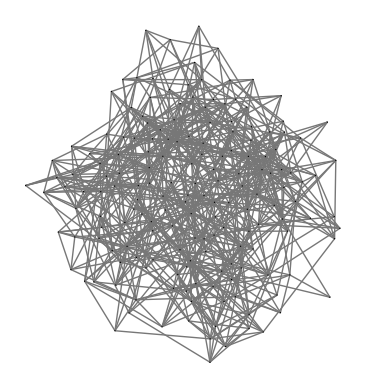

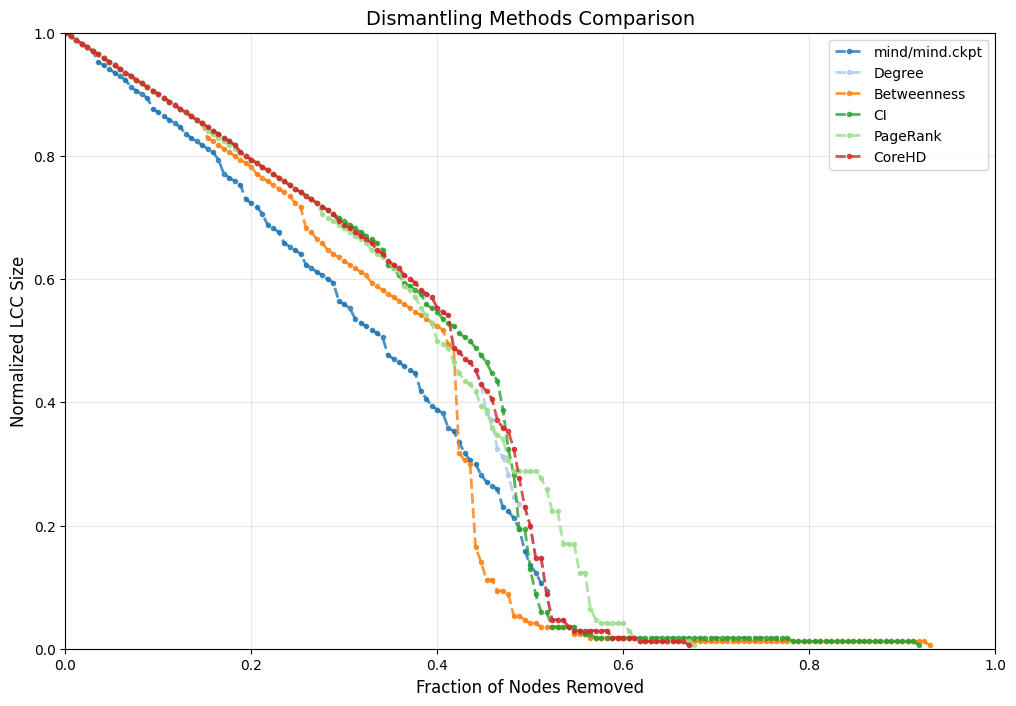

In [9]:
import igraph as ig
import os
import importlib
import baseline
import visualize_dismantling
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils import graph_models
importlib.reload(graph_models)
from utils.plot import plot_graph
from utils.common import load_g
from utils.graph_models import *
from baseline import baseline_dismantling,METHODS

# g = SBM(80,p_in=0.15,p_out=0.0075,num_blocks=2)
# g = SBM(96,p_in=0.12,p_out=0.01,num_blocks=3)
# g = SBM(200, p_in=0.3,p_out=0.01, num_blocks=2)
# g = DCSBM(120,p_in=0.3,p_out=0.01,num_blocks=5)
# g = ring_community(120,p_in=0.2,num_communities=4)
# g = star_community(120,p_in=0.15,num_communities=5)
# g = WS(80, k=8, p=0.5)
# g = barbell(120,p_in=0.1,path_len=3,type="ER")
# g = ER(120,0.05)
# g = BA(160,m=5)
g = load_g("graphs/demo/100_200_LFR_3000/00003.pkl",name='test')

g['name'] = 'test'
g = g.subgraph(max(g.connected_components(), key=len)) 
plot_graph(g)

all_results = {}
compare_mind_ckpts = [
                    'saved/mind/mind.ckpt'
                    ]

for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    gnn = ckpt_pth.split("/")[1]
    _, _, test_removals  = mind_wrapper(g,step_ratio=0.0,ckpt_pth=ckpt_pth,gnn=gnn)
    method_name = ckpt_pth.split("/",1)[-1]
    all_results[method_name] = test_removals

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    "Degree":METHODS['Degree'],
    "Betweenness":METHODS['Betweenness'],
    "CI": METHODS['CI'],
    "PageRank":METHODS['PageRank'],
    "CoreHD":METHODS['CoreHD'],
    # "MinSum":METHODS["MinSum"]
}
baseline_results = baseline_dismantling(g,methods,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

### compare mind_wrapper models

Graph: test, AUC=23.176707, Robustness=0.276818, Steps=63
Graph: test, AUC=23.569277, Robustness=0.281463, Steps=64
method Degree: AUC=34.084337349397586, Robustness=0.40513862679634194
method Betweenness: AUC=24.045180722891562, Robustness=0.2866889243721875
method CI: AUC=35.1726907630522, Robustness=0.4173319785164755
method FINDER: AUC=38.27309236947791, Robustness=0.4553636231673683


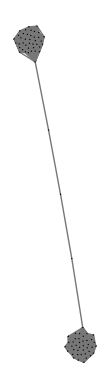

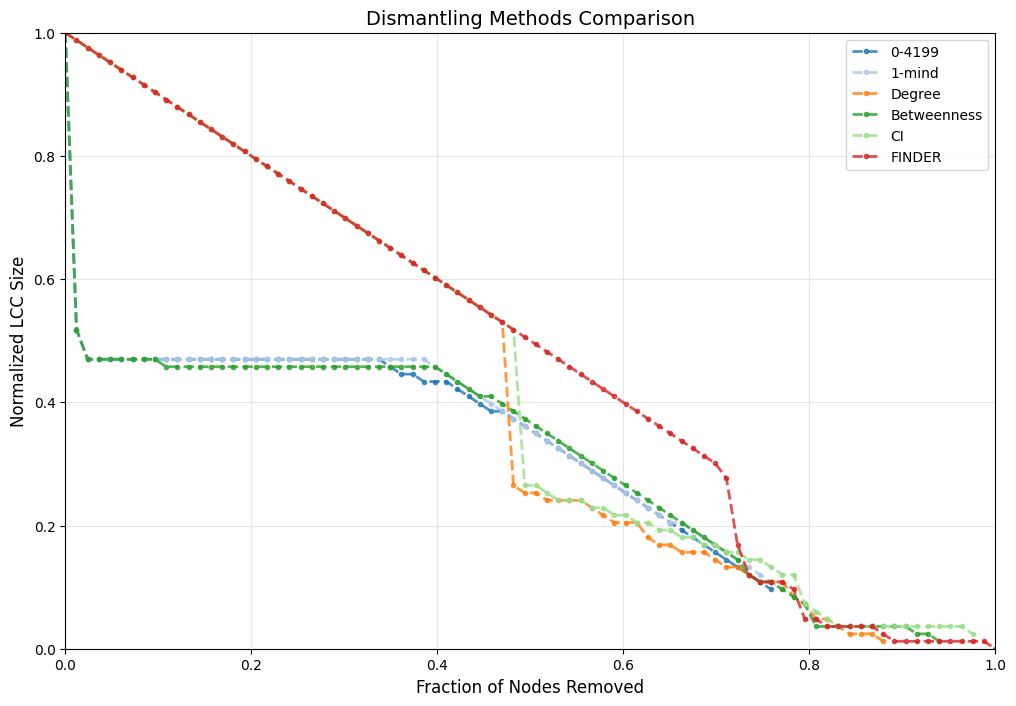

In [ ]:
import matplotlib.pyplot as plt
import importlib
import os
import utils
import visualize_dismantling
import baseline
from utils import graph_models
importlib.reload(graph_models)
importlib.reload(utils)
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils.common import load_g
from utils.plot import plot_graph
from visualize_dismantling import visualize_multiple_dynamic
from utils.graph_models import *

p_in = 0.7
p_out = 0.05
# g = SBM(120,p_in,p_out,3)
g = barbell(80,p_in,3)
g['name'] = 'test' 

plot_graph(g)
all_results = {}
compare_models = [
                    # 'saved/finetune_20251216_003004/7999.ckpt',
                    # 'saved/finetune_20251216_140104/2999.ckpt',
                    # 'saved/finetune_20251216_180547/9999.ckpt',
                    # 'saved/finetune_20251216_180547/7999.ckpt',
                    # 'saved/finetune_20251217_145647/5999.ckpt',
                    # 'saved/finetune_20251218_185945/13499.ckpt', #100-200,RGG
                    # 'saved/finetune_20251222_000136/6499.ckpt',  #100-200,SBM
                    # 'saved/finetune_20251222_210303/2999.ckpt',  #100-200,SBM,spectral
                    # 'saved/finetune_20251223_141913/2999.ckpt',   #100-200,SBM,betweenness  
                    # 'saved/finetune_prior_20251230_001358/2999.ckpt', #100-200,SBM,betweenness,prior 
                    # 'saved/finetune_prior_20251230_212246/3999.ckpt', #100-200,SBM,betweenness,prior
                    # "saved/finetune_20251231_163953/warmup/warmup_best_step_130_auc_0.2715.ckpt",
                    # "saved/finetune_20251231_172949/13999.ckpt",
                    "saved/finetune_20260102_101553/4199.ckpt",
                    'saved/mind.ckpt',
                    ]

for idx, ckpt_pth in enumerate(compare_models):
    _, _, test_removals  = mind_wrapper(g,step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = str(idx) + '-'+ os.path.basename(ckpt_pth).replace('.ckpt', '')
    all_results[method_name] = test_removals

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    "Degree":METHODS['Degree'],
    "Betweenness":METHODS['Betweenness'],
    "CI": METHODS['CI'],
    'FINDER':METHODS['FINDER']
}
baseline_results = baseline_dismantling(g,methods,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

# visualize_multiple_dynamic(g,all_results,output_dir="temp")


mind
Loaded graph test
Graph: test, AUC=25.655556, Robustness=0.210069, Steps=43
finetune_prior_20260121_203959
Loaded graph test
Graph: test, AUC=25.422222, Robustness=0.208194, Steps=41
sac_teacher_20260129_163549
Loaded graph test
Graph: test, AUC=24.529861, Robustness=0.200556, Steps=44
sac_graph_task_ewc_film_20260201_230504
Loaded graph test
Graph: test, AUC=30.319444, Robustness=0.248542, Steps=45
sac_graph_task_frozen_film_20260130_191042
Loaded graph test
Graph: test, AUC=29.908333, Robustness=0.245625, Steps=43
method Betweenness: AUC=23.205555555555556, Robustness=0.18937500000000004


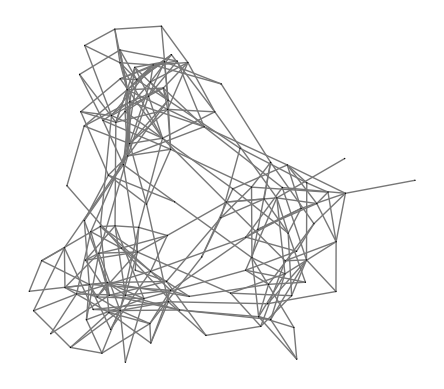

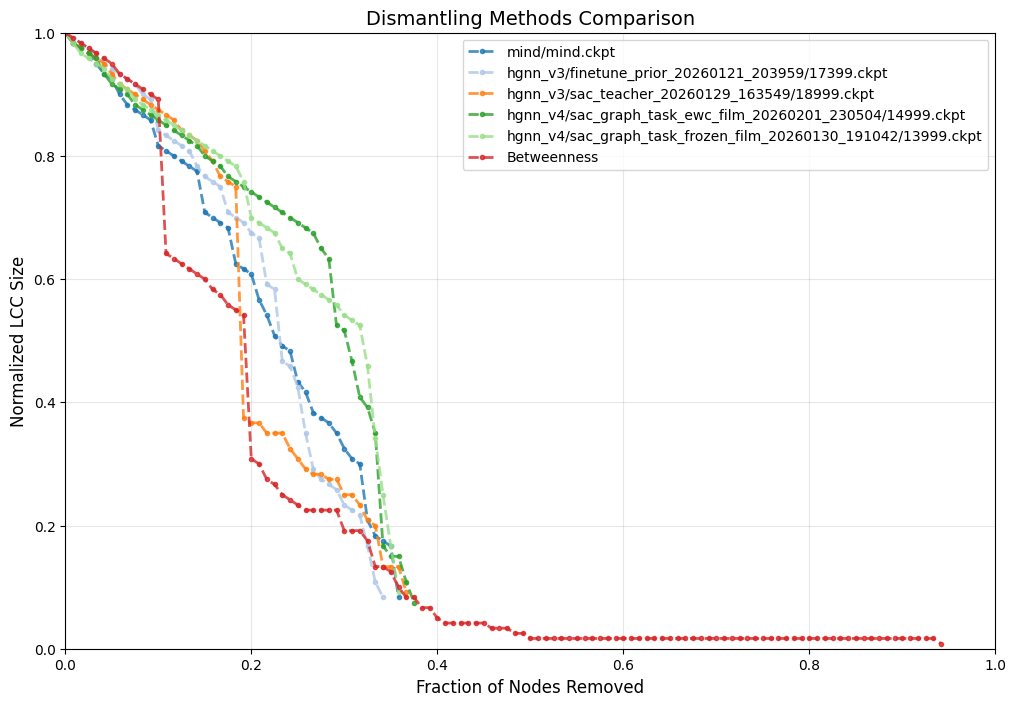

In [7]:
import igraph as ig
import os
import importlib
import baseline
import visualize_dismantling
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils import graph_models
importlib.reload(graph_models)
from utils.plot import plot_graph
from utils.common import load_g
from utils.graph_models import *
from baseline import baseline_dismantling,METHODS

g = SBM(80,p_in=0.15,p_out=0.0075,num_blocks=2)
g = SBM(120,p_in=0.12,p_out=0.007,num_blocks=3)
# g = SBM(200, p_in=0.3,p_out=0.01, num_blocks=2)
# g = DCSBM(120,p_in=0.3,p_out=0.01,num_blocks=5)
# g = ring_community(120,p_in=0.2,num_communities=4)
# g = star_community(120,p_in=0.15,num_communities=5)
# g = WS(80, k=8, p=0.5)
# g = barbell(120,p_in=0.1,path_len=3,type="ER")
# g = ER(80,0.2)
# g = BA(160,m=5)

g['name'] = 'test'
g = g.subgraph(max(g.connected_components(), key=len)) 
plot_graph(g)

all_results = {}
compare_mind_ckpts = [
                    'saved/mind/mind.ckpt',
                    # 'saved/finetune_prior_20260105_220540/2999.ckpt',
                    # 'saved/finetune_prior_20260106_075408/1999.ckpt',
                    # "saved/finetune_prior_20260106_151735/4799.ckpt", 
                    # "saved/finetune_prior_20260106_183209/4799.ckpt",
                    # "saved/finetune_prior_20260107_113306/5799.ckpt",
                    # "saved/finetune_prior_20260107_225616/5799.ckpt",
                    # "saved/finetune_20260107_163012/5799.ckpt",
                    # "saved/finetune_20260108_100547/5799.ckpt",
                    # "saved/finetune_prior_20260108_214004/6999.ckpt",
                    # "saved/finetune_prior_20260108_213417/19999.ckpt",
                    # "saved/finetune_prior_20260109_170406/9999.ckpt",
                    # "saved/finetune_prior_20260110_091248/13999.ckpt",
                    # "saved/finetune_prior_20260110_214344/13199.ckpt",
                    # "saved/finetune_prior_20260111_112035/5599.ckpt",
                    # "saved/finetune_prior_20260112_080602/8199.ckpt",
                    # "saved/mind/finetune_prior_20260112_113700/13799.ckpt",
                    # "saved/hgnn_v2/finetune_prior_20260120_200915/19999.ckpt",
                    # "saved/mind/finetune_prior_20260121_113317/19999.ckpt",
                    "saved/hgnn_v3/finetune_prior_20260121_203959/17399.ckpt",
                    "saved/hgnn_v3/sac_teacher_20260129_163549/18999.ckpt",
                    "saved/hgnn_v4/sac_graph_task_ewc_film_20260201_230504/14999.ckpt",
                    "saved/hgnn_v4/sac_graph_task_frozen_film_20260130_191042/13999.ckpt",
                    ]

for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    _, _, test_removals  = mind_wrapper(g,step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = ckpt_pth.split("/",1)[-1]
    all_results[method_name] = test_removals

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    # "Degree":METHODS['Degree'],
    "Betweenness":METHODS['Betweenness'],
    # "BetweennessNA":METHODS['BetweennessNA'],
    # "CI": METHODS['CI'],
    # 'FINDER':METHODS['FINDER']
}
baseline_results = baseline_dismantling(g,methods,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

mind
Loaded graph test
Graph: test, AUC=1.228205, Robustness=0.002564, Steps=7
finetune_prior_20260112_113700
Loaded graph test
Graph: test, AUC=7.746368, Robustness=0.018698, Steps=14
sac_teacher_20260129_163549
Loaded graph test
Graph: test, AUC=1.068162, Robustness=0.002255, Steps=6
sac_graph_task_fixed_film_20260130_191042
Loaded graph test
Graph: test, AUC=1.563675, Robustness=0.003557, Steps=8
method Degree: AUC=3.3626068376068368, Robustness=0.008139381985535833


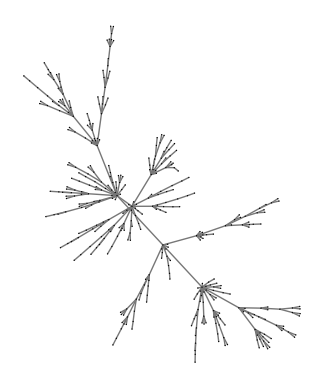

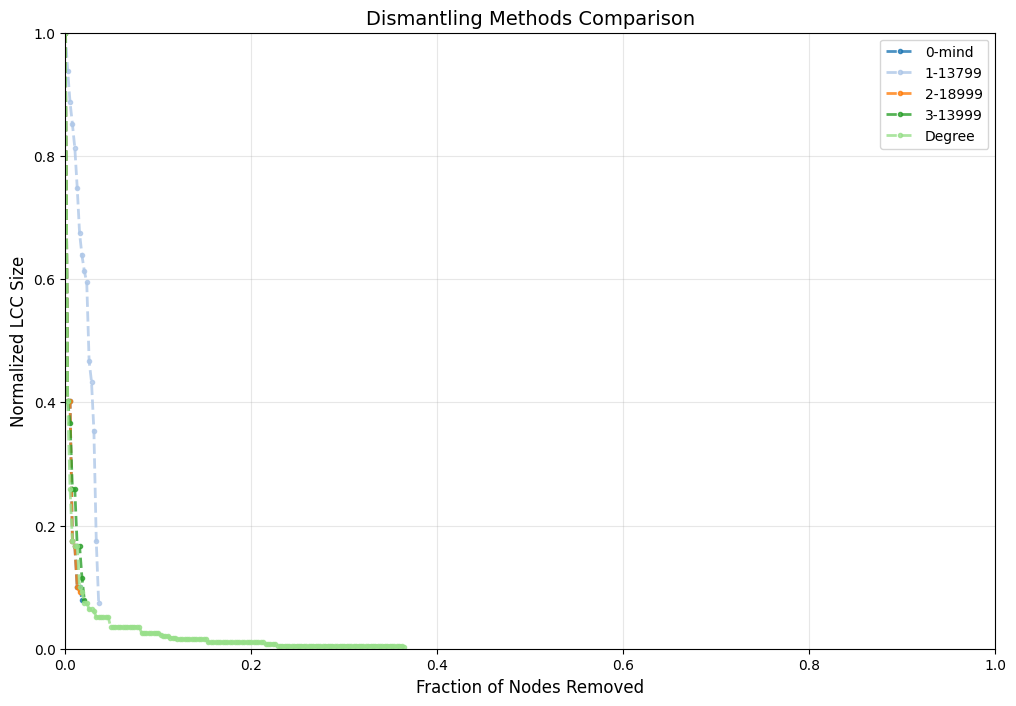

In [18]:
import matplotlib.pyplot as plt
import os
import importlib
import utils
import visualize_dismantling
import baseline
importlib.reload(utils)
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils.common import load_g
from utils.plot import plot_graph

g_name = 'test'
g = load_g(f'graphs/real/FINDER/Crime.pkl',name=g_name)
g = load_g(f'graphs/real/FINDER/Digg.pkl',name=g_name)
g = load_g(f'graphs/real/bio/arenas-meta.pkl',name=g_name)
g = load_g(f'graphs/real/bio/maayan-Stelzl.pkl',name=g_name)
# g = load_g(f'graphs/real/bio/maayan-figeys.pkl',name=g_name)
g = load_g(f'graphs/real/information/subelj_jdk_jdk.pkl',name=g_name)
# g = load_g(f'graphs/real/tech/gridkit-north_america.pkl',name=g_name)

# g = load_g(f'graphs/train/100_200_RGG_rw_2000/00008.pkl',name=g_name)
g = load_g(f'graphs/valid/valid/00001_BA.pkl',name=g_name)
# g = ig.Graph.GRG(n=500, radius=0.13)
# g['name'] = g_name

g_lcc = g.connected_components().giant()
plot_graph(g_lcc)

all_results = {}
compare_mind_ckpts = [
                    'saved/mind/mind.ckpt',
                    # 'saved/finetune_20251216_003004/7999.ckpt',
                    # 'saved/finetune_20251216_140104/2999.ckpt',
                    # 'saved/finetune_20251216_180547/9999.ckpt',
                    # 'saved/finetune_20251216_180547/7999.ckpt',
                    # 'saved/finetune_20251217_145647/5999.ckpt',
                    # 'saved/finetune_20251218_185945/13499.ckpt', #100-200,RGG
                    # 'saved/finetune_20251222_000136/6499.ckpt',  #100-200,SBM
                    # 'saved/finetune_20251222_210303/2999.ckpt',  #100-200,SBM,spectral
                    # 'saved/finetune_20251223_141913/2999.ckpt',   #100-200,SBM,betweenness
                    # 'saved/finetune_20251229_155032/2999.ckpt',  #100-200,SBM,betweenness,prior
                    # 'saved/finetune_20251230_001358/2999.ckpt', #100-200,SBM,betweenness,prior
                    # 'saved/finetune_20251230_212246/3999.ckpt', #100-200,SBM,betweenness,prior
                    # "saved/finetune_20251231_163953/warmup/warmup_best_step_130_auc_0.2715.ckpt",
                    # "saved/finetune_20251231_172949/13999.ckpt",
                    # "saved/finetune_20260101_131746/6199.ckpt",
                    # "saved/finetune_prior_20260110_214344/13199.ckpt",
                    "saved/mind/finetune_prior_20260112_113700/13799.ckpt",
                    "saved/hgnn_v3/sac_teacher_20260129_163549/18999.ckpt",
                    'saved/hgnn_v4/sac_graph_task_fixed_film_20260130_191042/13999.ckpt'
                    ]

for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    gnn = ckpt_pth.split("/")[1]
    _, _, test_removals  = mind_wrapper(g,step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = str(idx)+ '-' + os.path.basename(ckpt_pth).replace('.ckpt', '')
    all_results[method_name] = test_removals

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    "Degree":METHODS['Degree'],
    # "Betweenness":METHODS['Betweenness'],
    # "CI": METHODS['CI'],
    # 'FINDER':METHODS['FINDER']
}
baseline_results = baseline_dismantling(g,methods,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

# baselines

<Axes: >

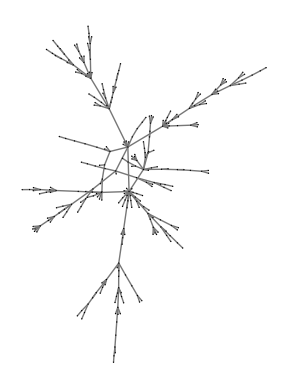

In [ ]:
#### BA 
G = ig.Graph.Barabasi(n=300, m=1, directed=False)
plot_graph(G)

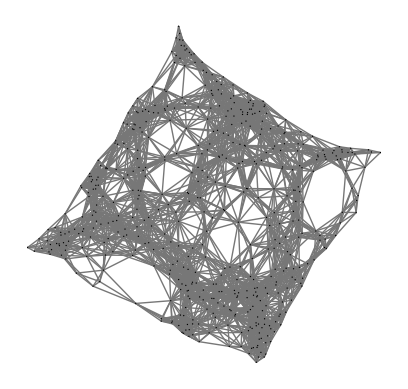

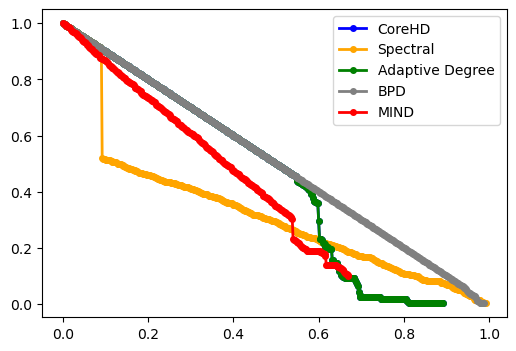

{}

In [ ]:
# Setup SBM
# Generate a 2D Random Geometric Graph
# n=500 nodes, radius=0.12 (threshold for connectivity)
G_rgg = ig.Graph.GRG(n=500, radius=0.12)
G_rgg.vs['static_id'] =list(range(G_rgg.vcount())) 
plot_graph(G_rgg)
benchmark_dismantling(G_rgg, methods)